# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [1]:
import pandas as pd
import numpy as np

In [2]:
orders_df = pd.read_csv('/datasets/instacart_orders.csv', sep=';')

In [3]:
products_df = pd.read_csv('/datasets/products.csv', sep=';')

In [4]:
aisles_df = pd.read_csv('/datasets/aisles.csv', sep=';')

In [5]:
departments_df = pd.read_csv('/datasets/departments.csv', sep=';')

In [6]:
order_products_df = pd.read_csv('/datasets/order_products.csv', sep=';')


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- precisa usar sep=';' ao ler o csv

</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>


### DataFrame `instacart_orders`

In [7]:
orders_df.duplicated().sum()

15

Há linhas duplicadas? Se sim, o que elas têm em comum?

In [8]:
# Com base nas suas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

In [9]:
print(orders_df.columns.tolist())

['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


In [10]:
print("Colunas após correção:")
print(orders_df.columns.tolist())

Colunas após correção:
['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


In [11]:

# Filtrar pedidos às 2h (hora 2) nas quartas-feiras (dia 3)

pedidos_2h_quarta = orders_df[(orders_df['order_hour_of_day'] == 2) & (orders_df['order_dow'] == 3)]
print(f"Pedidos às 2h nas quartas: {len(pedidos_2h_quarta)}"
)


Pedidos às 2h nas quartas: 121


O que esse resultado quer dizer?

In [12]:

# Verificar duplicados no orders_df

print("Total de linhas:", len(orders_df))
print("Linhas duplicadas completas:", orders_df.duplicated().sum())
print("Linhas únicas:", len(orders_df.drop_duplicates()))



Total de linhas: 478967
Linhas duplicadas completas: 15
Linhas únicas: 478952


In [13]:


# Para ver as duplicatas
duplicatas = orders_df[orders_df.duplicated(keep=False)]
print(duplicatas.head())



        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   

        days_since_prior_order  
30371                     16.0  
99462                      2.0  
119251                    18.0  
142258                     7.0  
145574                     2.0  


In [14]:
# Verificar duplicatas baseadas apenas no order_id


duplicatas_order_id = orders_df[orders_df.duplicated(subset=['order_id'], keep=False)]
print(f"Duplicatas baseadas em order_id: {len(duplicatas_order_id)}")





Duplicatas baseadas em order_id: 30


In [15]:

# Recarregar com o separador correto
# REMOVER DUPLICADOS

orders_df_clean = orders_df.drop_duplicates(subset=['order_id'], keep='first')
print(f"Linhas antes: {len(orders_df)}")
print(f"Linhas depois: {len(orders_df_clean)}")



Linhas antes: 478967
Linhas depois: 478952


In [16]:
# Verifique as linhas duplicadas mais uma vez

In [17]:
print("Duplicados restantes:", orders_df_clean.duplicated().sum())

Duplicados restantes: 0


In [18]:
# Verifique novamente apenas os IDs de pedidos duplicados

In [19]:

# Recarregar com o separador correto
orders_df_clean = orders_df.drop_duplicates(subset=['order_id'], keep='first')

# Opção 1: Usar o DataFrame limpo 
duplicatas_order_id = orders_df_clean[orders_df_clean.duplicated(subset=['order_id'], keep=False)]
print(f"Duplicatas baseadas em order_id: {len(duplicatas_order_id)}")


Duplicatas baseadas em order_id: 0


### DataFrame `products`

In [20]:
# Verifique se há linhas completamente duplicadas

In [21]:


print("Total de linhas:", len(products_df))
print("Linhas duplicadas completas:", products_df.duplicated().sum())
print("Linhas únicas:", len(products_df.drop_duplicates()))



Total de linhas: 49694
Linhas duplicadas completas: 0
Linhas únicas: 49694


In [22]:
# Verifique apenas IDs dos produtos duplicados

In [23]:

# Primeiro, recarregar products_df com o separador correto
# Agora verificar duplicatas baseadas em product_id
duplicatas_product_id = products_df[products_df.duplicated(subset=['product_id'], keep=False)]
print(f"Duplicatas baseadas em product_id: {len(duplicatas_product_id)}")




Duplicatas baseadas em product_id: 0


In [24]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)

In [25]:

duplicatas_nomes = (products_df['product_name']
                   .str.lower()
                   .duplicated())


In [26]:
# Verifique os nomes de produtos duplicados que não estão faltando

In [27]:


# Para ver quantos nomes duplicados existem
print(f"Nomes duplicados: {duplicatas_nomes.sum()}")


# Para ver os produtos com nomes duplicados
produtos_duplicados = products_df[duplicatas_nomes]
print(produtos_duplicados['product_name'])




Nomes duplicados: 1361
71                                                   NaN
109                                                  NaN
296                                                  NaN
416                                                  NaN
436                                                  NaN
                              ...                       
49689                      HIGH PERFORMANCE ENERGY DRINK
49690                      ORIGINAL PANCAKE & WAFFLE MIX
49691    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
49692                             SPRING WATER BODY WASH
49693                            BURRITO- STEAK & CHEESE
Name: product_name, Length: 1361, dtype: object


In [28]:


# Primeiro, recarregar products_df com o separador correto
print("Colunas após correção:")
print(products_df.columns.tolist())



# Agora verificar duplicatas baseadas em product_name

duplicatas_product_name = products_df[products_df.duplicated(subset=['product_name'], keep=False)]
print(f"Duplicatas baseadas em product_name: {len(duplicatas_product_name)}")



Colunas após correção:
['product_id', 'product_name', 'aisle_id', 'department_id']
Duplicatas baseadas em product_name: 1258


Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `departments`

In [29]:
# Verifique se há linhas completamente duplicadas

In [30]:
print("Linhas duplicadas completas:", departments_df.duplicated().sum())

Linhas duplicadas completas: 0


In [31]:
# Verifique apenas se há IDs dos produtos duplicados

In [32]:


# Para verificar duplicatas baseadas em product_id
duplicatas_product_id = products_df[products_df.duplicated(subset=['product_id'], keep=False)]
print(f"Duplicatas baseadas em product_id: {len(duplicatas_product_id)}")




Duplicatas baseadas em product_id: 0


Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `aisles`

In [33]:
# Verifique se há linhas completamente duplicadas

In [34]:
print("Linhas duplicadas completas:", aisles_df.duplicated().sum())

Linhas duplicadas completas: 0


In [35]:
# Verifique apenas se há IDs dos produtos duplicados

In [36]:
print(aisles_df.columns.tolist())

['aisle_id', 'aisle']


In [37]:

duplicatas = aisles_df['aisle_id'].duplicated().sum()
print(f"Número de IDs duplicados: {duplicatas}")


Número de IDs duplicados: 0


Os dados estão limpos e não precisamos fazer nenhuma correção.

<div class="alert alert-block alert-danger">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Erro de execução. Reforço o comentário da iteração anterior: 1) use sep=';' na leitura do csv logo após importações; 2) elimine leitura csv repetida 
</div>



<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>


### DataFrame `order_products`

In [38]:
# Verifique se há linhas completamente duplicadas

In [39]:
print(order_products_df.columns.tolist())


['order_id', 'product_id', 'add_to_cart_order', 'reordered']


In [40]:

total_linhas = len(order_products_df)
ids_unicos = order_products_df['order_id'].nunique()
print(f"Total de linhas: {total_linhas}")
print(f"IDs únicos: {ids_unicos}")


Total de linhas: 4545007
IDs únicos: 450046


In [41]:
print("Linhas duplicadas completas:", order_products_df.duplicated().sum())

Linhas duplicadas completas: 0


In [42]:
# Verifique mais uma vez se há outros casos complicados de duplicados

Descreva brevemente suas conclusões e o que você fez com elas.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [43]:
# Encontre valores ausentes na coluna 'product_name'

In [44]:

print("Colunas do products_df:")
print(products_df.columns.tolist())


Colunas do products_df:
['product_id', 'product_name', 'aisle_id', 'department_id']


In [45]:

# Verificar as primeiras linhas
print("\nPrimeiras 5 linhas:")
print(products_df.head())



Primeiras 5 linhas:
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  


In [46]:

valores_ausentes = products_df['product_name'].isnull().sum()
print(f"Número de valores ausentes em 'product_name': {valores_ausentes}")


Número de valores ausentes em 'product_name': 1258


Descreva brevemente suas conclusões.

In [47]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?

In [48]:

# Encontrar produtos com nomes ausentes
produtos_sem_nome = products_df[products_df['product_name'].isnull()]
print(f"Número de produtos sem nome: {len(produtos_sem_nome)}")
print("\nPrimeiros produtos sem nome:")
print(produtos_sem_nome.head()
)

Número de produtos sem nome: 1258

Primeiros produtos sem nome:
     product_id product_name  aisle_id  department_id
37           38          NaN       100             21
71           72          NaN       100             21
109         110          NaN       100             21
296         297          NaN       100             21
416         417          NaN       100             21


Descreva brevemente suas conclusões.

In [49]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?

In [50]:

# Verificar os aisle_id dos produtos sem nome

corredores_sem_nome = produtos_sem_nome['aisle_id'].unique()
print(f"Corredores dos produtos sem nome: {corredores_sem_nome}")



Corredores dos produtos sem nome: [100]


In [51]:

# Recarregar o DataFrame e recriar a variável produtos_sem_nome

produtos_sem_nome = products_df[products_df['product_name'].isnull()]
print(f"Número de produtos sem nome: {len(produtos_sem_nome)}")



# Verificar os departamentos dos produtos sem nome
departamentos_sem_nome = produtos_sem_nome['department_id'].value_counts()
print("Distribuição por departamento dos produtos sem nome:")
print(departamentos_sem_nome)

# Verificar se TODOS estão no departamento 21

todos_dept_21 = produtos_sem_nome['department_id'].eq(21).all()
print(f"\nTodos os produtos sem nome estão no departamento 21? {todos_dept_21}")




Número de produtos sem nome: 1258
Distribuição por departamento dos produtos sem nome:
21    1258
Name: department_id, dtype: int64

Todos os produtos sem nome estão no departamento 21? True



<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Correto. Usou  value_counts() na coluna para avlaiar se há algum outro valor além do informado
- Porém precisa fazer também para department_id
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>



Descreva brevemente suas conclusões.

In [52]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.

In [53]:
# Verificar se todos os produtos sem nome estão no corredor 100
todos_corredor_100 = produtos_sem_nome['aisle_id'].eq(100).all()
print(f"Todos os produtos sem nome estão no corredor 100? {todos_corredor_100}")

# Contar quantos estão no corredor 100
no_corredor_100 = produtos_sem_nome['aisle_id'].eq(100).sum()
total_sem_nome = len(produtos_sem_nome)
print(f"Produtos sem nome no corredor 100: {no_corredor_100} de {total_sem_nome}")

Todos os produtos sem nome estão no corredor 100? True
Produtos sem nome no corredor 100: 1258 de 1258


In [54]:

# Verificar se produtos do corredor 100 estão no departamento 21

produtos_100_e_21 = products_df[(products_df['aisle_id'] == 100) & 
                                (products_df['department_id'] == 21)]
print(f"Produtos que estão no corredor 100 E departamento 21: {len(produtos_100_e_21)}")



Produtos que estão no corredor 100 E departamento 21: 1258


In [55]:

# Produtos no departamento 21
produtos_departamento_21 = products_df[products_df['department_id'] == 21]
print(f"Número de produtos no departamento 21: {len(produtos_departamento_21)}")
print("\nPrimeiros produtos do departamento 21:")
print(produtos_departamento_21.head())


Número de produtos no departamento 21: 1258

Primeiros produtos do departamento 21:
     product_id product_name  aisle_id  department_id
37           38          NaN       100             21
71           72          NaN       100             21
109         110          NaN       100             21
296         297          NaN       100             21
416         417          NaN       100             21


In [56]:
# Preencha nomes de produtos ausentes com 'Unknown'

In [57]:
# Criar uma cópia do DataFrame original
df_products_copy = products_df.copy()

In [58]:
df_products_copy['product_name'].fillna('unknown')

0                               Chocolate Sandwich Cookies
1                                         All-Seasons Salt
2                     Robust Golden Unsweetened Oolong Tea
3        Smart Ones Classic Favorites Mini Rigatoni Wit...
4                                Green Chile Anytime Sauce
                               ...                        
49689                        HIGH PERFORMANCE ENERGY DRINK
49690                        ORIGINAL PANCAKE & WAFFLE MIX
49691      ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
49692                               SPRING WATER BODY WASH
49693                              BURRITO- STEAK & CHEESE
Name: product_name, Length: 49694, dtype: object

Descreva brevemente suas conclusões.

Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `orders`

In [59]:
# Encontre os valores ausentes

In [60]:

valores_ausentes = orders_df['days_since_prior_order'].isnull().sum()
print(f"Número de valores ausentes em 'days_since_prior_order': {valores_ausentes}")



Número de valores ausentes em 'days_since_prior_order': 28819


In [61]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?

In [62]:

# Filtrar pedidos onde order_number > 1
pedidos_nao_primeiro = orders_df[orders_df['order_number'] > 1]


In [63]:
# Contar valores ausentes
valores_ausentes = pedidos_nao_primeiro['days_since_prior_order'].isnull().sum()

In [64]:
print(f"Valores ausentes para clientes que não estão no primeiro pedido: {valores_ausentes}")

Valores ausentes para clientes que não estão no primeiro pedido: 0


Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `order_products`

In [65]:
# Encontre os valores ausentes

In [66]:
# Primeiro, recarregar o DataFrame

In [67]:
# Depois verificar valores ausentes no order_id

valores_ausentes_order_id = order_products_df['order_id'].isnull().sum()
print(f"Valores ausentes em 'order_id': {valores_ausentes_order_id}")



Valores ausentes em 'order_id': 0


In [68]:

# Análise completa
print("=== ANÁLISE COMPLETA DE VALORES AUSENTES ===")
print(f"Formato do DataFrame: {order_products_df.shape}")
print("\nValores ausentes por coluna:")
print(order_products_df.isnull().sum())
print("\nPercentual de valores ausentes:")
print((order_products_df.isnull().sum() / len(order_products_df)) * 100)


=== ANÁLISE COMPLETA DE VALORES AUSENTES ===
Formato do DataFrame: (4545007, 4)

Valores ausentes por coluna:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

Percentual de valores ausentes:
order_id             0.000000
product_id           0.000000
add_to_cart_order    0.018394
reordered            0.000000
dtype: float64


In [69]:
# Quais são os valores mínimo e máximo dessa coluna?

Descreva brevemente suas conclusões.

In [70]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'

In [71]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem


In [72]:
# Recarregar o DataFrame para garantir que está correto
# Identificar linhas com valores ausentes na coluna 'add_to_cart_order'
mask_ausentes = order_products_df['add_to_cart_order'].isna()

# Ver quantas linhas têm valores ausentes

total_ausentes = mask_ausentes.sum()
print(f"Linhas com valores ausentes: {total_ausentes}")

# Salvar todos os IDs dos pedidos com pelo menos um valor ausente

pedidos_com_ausentes = order_products_df[mask_ausentes]['order_id'].unique()
print(f"Número de pedidos únicos com valores ausentes: {len(pedidos_com_ausentes)}")




Linhas com valores ausentes: 836
Número de pedidos únicos com valores ausentes: 70


In [73]:
# Agrupe os pedidos com dados ausentes por ID de pedido

In [74]:

 miss_cart_order_ids = sorted(list(order_products_df[order_products_df['add_to_cart_order'].isna()]['order_id'].unique()))
 order_products_df[order_products_df['order_id'].isin(miss_cart_order_ids)].groupby('order_id').size().sort_values()


order_id
9310        65
747668      65
1598369     65
1677118     65
2170451     65
          ... 
1959075     98
171934     104
2136777    108
3308010    115
61355      127
Length: 70, dtype: int64


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- erro de lógica. deixo dica abaixo
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>



In [75]:

# miss_cart_order_ids = sorted(list(order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()))
# order_products[order_products['order_id'].isin(miss_cart_order_ids)].groupby('order_id').size().sort_values()


Descreva brevemente suas conclusões.

Descreva brevemente suas conclusões e o que você fez com elas.

In [76]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer

In [77]:
#  Modificar diretamente a coluna
order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].fillna(999)

# Converter para tipo integer
order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].astype(int)


# Verifique se ainda há valores ausentes
print("Valores ausentes após o preenchimento:", order_products_df['add_to_cart_order'].isnull().sum())

# Verifique o tipo de dados da coluna
print("Tipo de dados:", order_products_df['add_to_cart_order'].dtype)

# Veja alguns valores para confirmar
print("Primeiros valores da coluna:")
print(order_products_df['add_to_cart_order'].head(10))


Valores ausentes após o preenchimento: 0
Tipo de dados: int64
Primeiros valores da coluna:
0    17
1     1
2     1
3    35
4     5
5     4
6     5
7    10
8    14
9     4
Name: add_to_cart_order, dtype: int64


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [78]:
# Verificar valores únicos e seus intervalos

print("Valores únicos em 'order_hour_of_day':")
print(f"Mínimo: {orders_df['order_hour_of_day'].min()}")
print(f"Máximo: {orders_df['order_hour_of_day'].max()}")
print(f"Valores únicos: {sorted(orders_df['order_hour_of_day'].unique())}")



Valores únicos em 'order_hour_of_day':
Mínimo: 0
Máximo: 23
Valores únicos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


Escreva suas conclusões aqui

In [79]:


# Primeiro, certifique-se de que o DataFrame está carregado
# Conte quantos pedidos acontecem em cada hora

pedidos_por_hora = orders_df['order_hour_of_day'].value_counts().sort_index()
print(pedidos_por_hora)




0      3180
1      1763
2      1004
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

In [80]:
# Hora 0 (meia-noite): 3.180 pedidos
# Pico de pedidos entre 10h-15h (mais de 35.000 pedidos por hora)
# Menor atividade durante a madrugada (2h-4h)

Escreva suas conclusões aqui

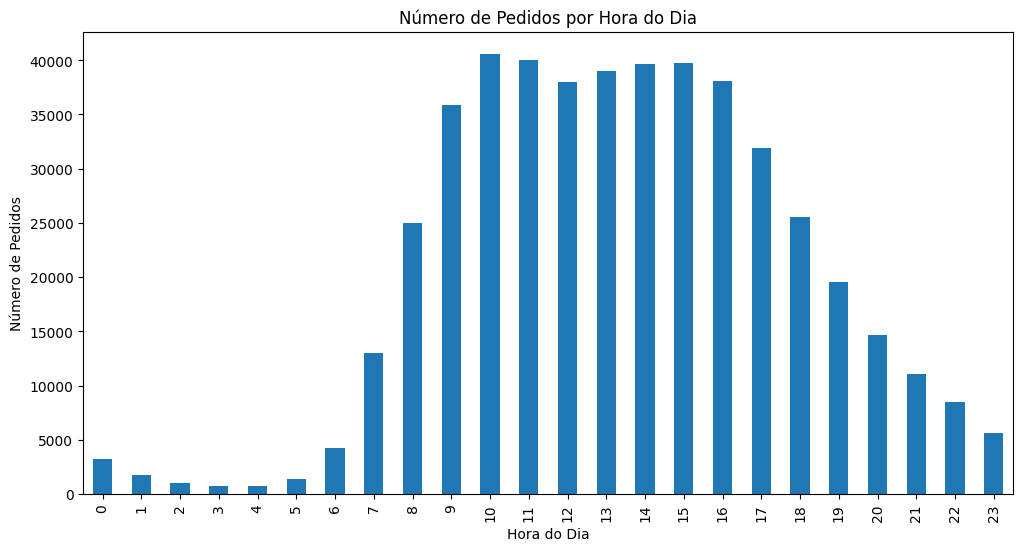

In [81]:
# DataFrame carregado
# pedidos_por_hora
pedidos_por_hora = orders_df['order_hour_of_day'].value_counts().sort_index()

# gráfico

import matplotlib.pyplot as plt
pedidos_por_hora.plot(kind='bar',
                      figsize=(12, 6),
                      title='Número de Pedidos por Hora do Dia',
                      xlabel='Hora do Dia',
                      ylabel='Número de Pedidos')
plt.show()




<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- gráfico de barras é o ideal
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>



### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

In [82]:
# 0 (Domingo): 84.090 pedidos - DIA MAIS MOVIMENTADO! 🏆
# 1 (Segunda): 82.185 pedidos - segundo lugar
# 2 (Terça): 65.833 pedidos
# 3 (Quarta): 60.912 pedidos
# 4 (Quinta): 59.810 pedidos - DIA MENOS MOVIMENTADO
# 5 (Sexta): 63.488 pedidos
# 6 (Sábado): 62.649 pedidos


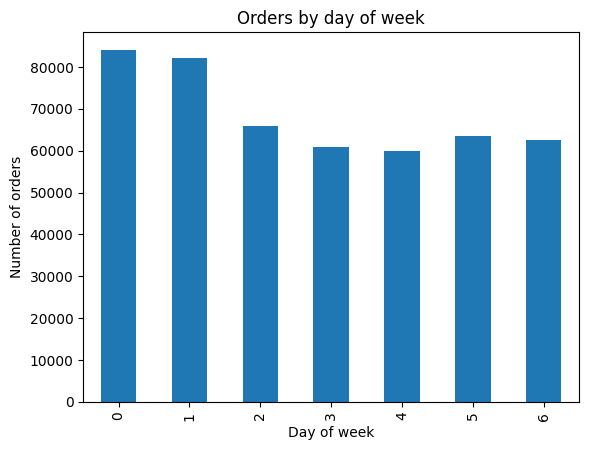

In [83]:

 day_of_week_counts = orders_df['order_dow'].value_counts().sort_index()
 day_of_week_counts.plot(kind='bar',
                         title='Orders by day of week',
                         xlabel='Day of week',
                         ylabel='Number of orders'
                        )
 plt.show()

Escreva suas conclusões aqui


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- deixo dica abaixo
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>



In [84]:

# day_of_week_counts = orders['order_dow'].value_counts().sort_index()
# day_of_week_counts.plot(kind='bar',
#                         title='Orders by day of week',
#                         xlabel='Day of week',
#                         ylabel='Number of orders'
#                        )
# plt.show()


### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui

In [85]:

# - min: 0 dias - algumas pessoas fazem pedidos no mesmo dia!
# - max: 30 dias - outras esperam até 30 dias
# - mediana (50%): 7 dias - metade das pessoas espera 7 dias ou menos
# - 25% e 75%: A maioria das pessoas espera entre 4 e 15 dias


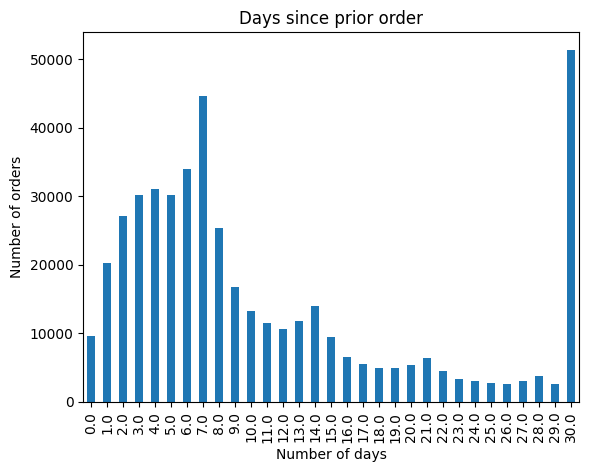

In [86]:
 orders_df['days_since_prior_order'].value_counts().sort_index().plot(kind='bar',
                                                                   title='Days since prior order',
                                                                   xlabel='Number of days',
                                                                   ylabel='Number of orders'
                                                                  )
 plt.show()



<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- deixo dica abaixo
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>



In [87]:

# orders['days_since_prior_order'].value_counts().sort_index().plot(kind='bar',
#                                                                   title='Days since prior order',
#                                                                   xlabel='Number of days',
#                                                                   ylabel='Number of orders'
#                                                                  )
# plt.show()


# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# Recarregar os dados

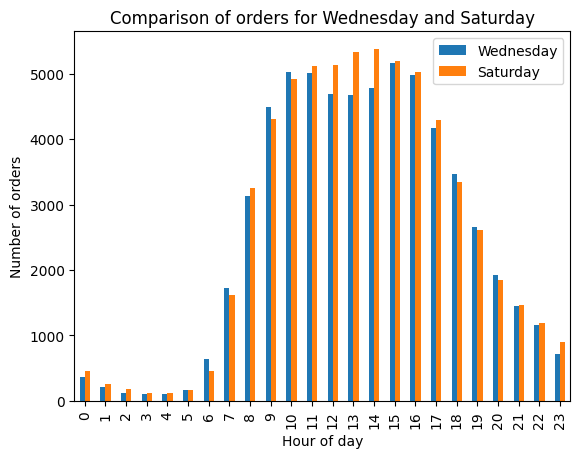

In [89]:

wed_mask = orders_df['order_dow'] == 3
hod_counts_wed = orders_df[wed_mask]['order_hour_of_day'].value_counts().sort_index()
sat_mask = orders_df['order_dow'] == 6
hod_counts_sat = orders_df[sat_mask]['order_hour_of_day'].value_counts().sort_index()
hod_counts = pd.concat([hod_counts_wed, hod_counts_sat], axis=1)
hod_counts.columns = ['Wednesday', 'Saturday']

hod_counts.plot(kind='bar',
                 title='Comparison of orders for Wednesday and Saturday',
                 xlabel='Hour of day',
                 ylabel='Number of orders'
                )
plt.show()


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- deixo dica abaixo
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>



In [90]:

# wed_mask = orders['order_dow'] == 3
# hod_counts_wed = orders[wed_mask]['order_hour_of_day'].value_counts().sort_index()
# sat_mask = orders['order_dow'] == 6
# hod_counts_sat = orders[sat_mask]['order_hour_of_day'].value_counts().sort_index()
# hod_counts = pd.concat([hod_counts_wed, hod_counts_sat], axis=1)
# hod_counts.columns = ['Wednesday', 'Saturday']

# hod_counts.plot(kind='bar',
#                 title='Comparison of orders for Wednesday and Saturday',
#                 xlabel='Hour of day',
#                 ylabel='Number of orders'
#                )
# plt.show()


Escreva suas conclusões aqui

### [B2] Qual é a distribuição do número de pedidos por cliente?

<div class="alert alert-block alert-danger">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

ausente.
</div>



<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

Correto
</div>



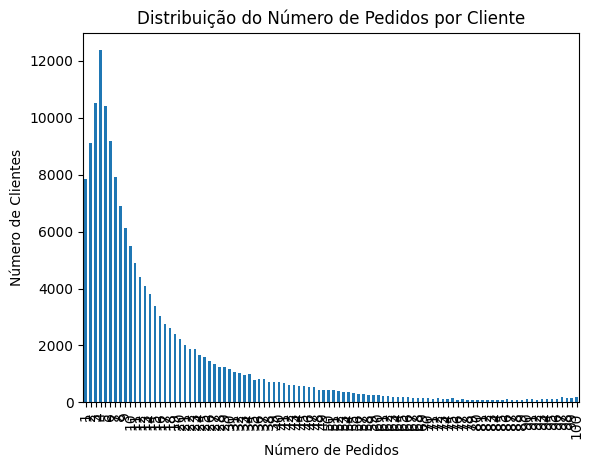

In [91]:

# Passo 1: Para cada cliente (user_id), qual o maior order_number?
pedidos_por_cliente = orders_df.groupby('user_id')['order_number'].max()

# Passo 2: Quantos clientes têm cada quantidade de pedidos?
distribuicao_pedidos = pedidos_por_cliente.value_counts().sort_index()

# Passo 3: Criar o gráfico
distribuicao_pedidos.plot(kind='bar',
                         title='Distribuição do Número de Pedidos por Cliente',
                         xlabel='Número de Pedidos',
                         ylabel='Número de Clientes')
plt.show()


In [92]:

# Ver os dados numéricos por trás do gráfico
print("Distribuição do número de pedidos por cliente:")
print(distribuicao_pedidos.head(10))

# Estatísticas descritivas
print(f"\nEstatísticas:")
print(f"Número médio de pedidos por cliente: {pedidos_por_cliente.mean():.2f}")
print(f"Número máximo de pedidos: {pedidos_por_cliente.max()}")
print(f"Número mínimo de pedidos: {pedidos_por_cliente.min()}")


Distribuição do número de pedidos por cliente:
1      7840
2      9113
3     10510
4     12368
5     10406
6      9194
7      7901
8      6894
9      6118
10     5497
Name: order_number, dtype: int64

Estatísticas:
Número médio de pedidos por cliente: 15.58
Número máximo de pedidos: 100
Número mínimo de pedidos: 1


Curva de retenção típica: A maioria dos clientes faz poucos pedidos, mas há um grupo leal que faz muitos pedidos
Oportunidade de retenção: Os 7.840 clientes com apenas 1 pedido representam uma oportunidade de melhoria na retenção
Clientes valiosos: Aqueles com 10+ pedidos são extremamente valiosos para o negócio

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

<div class="alert alert-block alert-danger">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

ausente.
</div>



<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

Correto
</div>



In [93]:


produtos_populares = order_products_df['product_id'].value_counts()
print (produtos_populares)



24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
         ...  
10543        1
5222         1
2347         1
11893        1
32074        1
Name: product_id, Length: 45573, dtype: int64


In [94]:



top_20_produtos = order_products_df['product_id'].value_counts().head(20).reset_index()
print (top_20_produtos)




    index  product_id
0   24852       66050
1   13176       53297
2   21137       37039
3   21903       33971
4   47209       29773
5   47766       24689
6   47626       21495
7   16797       20018
8   26209       19690
9   27845       19600
10  27966       19197
11  22935       15898
12  24964       15292
13  45007       14584
14  39275       13879
15  49683       13675
16  28204       12544
17   5876       12232
18   8277       11993
19  40706       11781


In [95]:
# 1) Ajustar nomes de colunas
top_20_produtos = (
    order_products_df['product_id']
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'index': 'product_id', 'product_id': 'purchase_count'})
)

# 2) Garantir tipo compatível (se necessário)
top_20_produtos['product_id'] = top_20_produtos['product_id'].astype(products_df['product_id'].dtype)

# 3) Merge para obter nomes
top_20_com_nomes = top_20_produtos.merge(products_df[['product_id', 'product_name']],
                                         on='product_id',
                                         how='left')

# 4) Tratar nomes ausentes (opcional)
top_20_com_nomes['product_name'] = top_20_com_nomes['product_name'].fillna('unknown')

print(top_20_com_nomes)

    product_id  purchase_count              product_name
0        24852           66050                    Banana
1        13176           53297    Bag of Organic Bananas
2        21137           37039      Organic Strawberries
3        21903           33971      Organic Baby Spinach
4        47209           29773      Organic Hass Avocado
5        47766           24689           Organic Avocado
6        47626           21495               Large Lemon
7        16797           20018              Strawberries
8        26209           19690                     Limes
9        27845           19600        Organic Whole Milk
10       27966           19197       Organic Raspberries
11       22935           15898      Organic Yellow Onion
12       24964           15292            Organic Garlic
13       45007           14584          Organic Zucchini
14       39275           13879       Organic Blueberries
15       49683           13675            Cucumber Kirby
16       28204           12544 

Escreva suas conclusões aqui

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


<s>
    <div class="alert alert-block alert-danger">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

ausente.
</div>



### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

Escreva suas conclusões aqui

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [96]:

# Filtrar apenas pedidos repetidos
pedidos_repetidos = order_products_df[order_products_df['reordered'] == 1]
print (pedidos_repetidos)


         order_id  product_id  add_to_cart_order  reordered
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          491251        8670                 35          1
4         2571142        1940                  5          1
5         2456893       21616                  4          1
...           ...         ...                ...        ...
4544999   1622300       24852                  1          1
4545000   1125324       40600                  6          1
4545002    577211       15290                 12          1
4545004    692640       47766                  4          1
4545005    319435         691                  8          1

[2683838 rows x 4 columns]


In [97]:

# Passo 1: Contar frequência dos produtos em pedidos repetidos
top_20_repetidos = pedidos_repetidos['product_id'].value_counts().head(20)

# Passo 2: Transformar em DataFrame e renomear colunas
top_20_repetidos_df = (
    top_20_repetidos
    .reset_index()
    .rename(columns={'index': 'product_id', 'product_id': 'reorder_count'})
)

# Passo 3: Fazer merge com products_df para obter nomes
resultado_c2 = top_20_repetidos_df.merge(
    products_df[['product_id', 'product_name']], 
    on='product_id', 
    how='left'
)

print(resultado_c2)


    product_id  reorder_count              product_name
0        24852          55763                    Banana
1        13176          44450    Bag of Organic Bananas
2        21137          28639      Organic Strawberries
3        21903          26233      Organic Baby Spinach
4        47209          23629      Organic Hass Avocado
5        47766          18743           Organic Avocado
6        27845          16251        Organic Whole Milk
7        47626          15044               Large Lemon
8        27966          14748       Organic Raspberries
9        16797          13945              Strawberries
10       26209          13327                     Limes
11       22935          11145      Organic Yellow Onion
12       24964          10411            Organic Garlic
13       45007          10076          Organic Zucchini
14       49683           9538            Cucumber Kirby
15       28204           8989        Organic Fuji Apple
16        8277           8836  Apple Honeycrisp 

Escreva suas conclusões aqui

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [98]:
# Total de pedidos por produto (todos os produtos)
total_pedidos = order_products_df['product_id'].value_counts().reset_index()
total_pedidos.columns = ['product_id', 'total_count']

# Total de reordens por produto (todos os produtos)
total_reordens = pedidos_repetidos['product_id'].value_counts().reset_index()
total_reordens.columns = ['product_id', 'reorder_count']

In [99]:

# Juntar os dados
proporcoes = total_pedidos.merge(total_reordens, on='product_id', how='left')

# Preencher NaN com 0 (produtos que nunca foram reordenados)
proporcoes['reorder_count'] = proporcoes['reorder_count'].fillna(0)

# Calcular a proporção
proporcoes['proporcao_reordens'] = proporcoes['reorder_count'] / proporcoes['total_count']


In [100]:

# Adicionar nomes dos produtos
resultado_final = proporcoes.merge(products_df[['product_id', 'product_name']], 
                                   on='product_id', 
                                   how='left')

# Preencher nomes ausentes
resultado_final['product_name'] = resultado_final['product_name'].fillna('Unknown')

# Ordenar por proporção (maior para menor)
resultado_final = resultado_final.sort_values('proporcao_reordens', ascending=False)

# Exibir os top 20 produtos com maior proporção de reordens
print("Top 20 produtos com maior proporção de reordens:")
print(resultado_final[['product_id', 'product_name', 'proporcao_reordens']].head(20))


Top 20 produtos com maior proporção de reordens:
       product_id                                       product_name  \
38106       24274                   Fat Free American Cheese Singles   
39014       31852                                 San Ignacio Coffee   
39021       13622                       Charcoal Briquettes Mesquite   
39022       27728                    Instant Rolled Oats Whole Grain   
39025       31566                                Nasal Allergy Spray   
39029       26942             Whitening Toothpaste with Tea Tree Oil   
39032        4507                                            Unknown   
39040       42348                            Fruit Punch Fruit Drink   
39050       33870                Bonito Del Norte En Aceita De Oliva   
39071       19554                     24 Hr 20mg Acid Reducer Tablet   
39121       18736                   Sorta Sweet Straight Up Iced Tea   
39146        2899                         Astragalus Supreme Extract   
39149       479

<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

A lógica parece correta. Porém, deixo abaixo código mais enxuto
</div>



In [103]:
df_merge = order_products_df.merge(products_df)
reorder_rate = df_merge.groupby(['product_id', 'product_name'])['reordered'].mean()
reorder_rate

product_id  product_name                                                     
1           Chocolate Sandwich Cookies                                           0.564286
2           All-Seasons Salt                                                     0.000000
3           Robust Golden Unsweetened Oolong Tea                                 0.738095
4           Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce    0.510204
7           Pure Coconut Water With Orange                                       0.500000
                                                                                   ...   
49690       HIGH PERFORMANCE ENERGY DRINK                                        0.800000
49691       ORIGINAL PANCAKE & WAFFLE MIX                                        0.430556
49692       ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR                      0.416667
49693       SPRING WATER BODY WASH                                               0.440000
49694       BURRITO- S

Escreva suas conclusões aqui

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

Escreva suas conclusões aqui

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

Escreva suas conclusões aqui

# Conclusão geral do projeto: